# B4 — Fine-tuning PEGASUS avec LoRA (GPU T4)
**Personne B** | Phase 2 : Pipeline & Modèle

> **Input :** `donnees_propres.json` ← Personne A  
> **Output :** `model_finetuned/` → pour Personne A (Pipeline Map-Reduce)

**Technique :** LoRA + quantization 8-bit → PEGASUS dans 14 GB VRAM

## 0. Installation

In [1]:
import subprocess
subprocess.run([
    "pip", "install",
    "transformers", "rouge-score", "sentencepiece",
    "accelerate", "bitsandbytes", "peft", "-q"
])

CompletedProcess(args=['pip', 'install', 'transformers', 'rouge-score', 'sentencepiece', 'accelerate', 'bitsandbytes', 'peft', '-q'], returncode=0)

## 1. Imports & Configuration

In [ ]:
import os, gc, json, time, torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from transformers import get_linear_schedule_with_warmup
from peft import get_peft_model, LoraConfig, TaskType
from torch.optim import AdamW
from rouge_score import rouge_scorer as rs
c:\Users\pc\Downloads\04_B4_finetuning_lora (1).ipynb
MODEL_NAME = "google/pegasus-xsum"
MAX_INPUT  = 256
MAX_TARGET = 128   # ✅ corrigé : 64 → 128 (capture mieux les résumés)

HYPERPARAMS = {
    "num_epochs":                  3,
    "batch_size":                  1,
    "learning_rate":               5e-5,   # ✅ corrigé : 3e-4 → 5e-5 (plus stable)
    "weight_decay":                0.01,
    "warmup_steps":                100,    # ✅ corrigé : 50 → 100 (warmup plus long)
    "gradient_accumulation_steps": 8,
    "output_dir":                  "model_finetuned"
}

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device     : {device}")
print(f"Modele     : {MODEL_NAME}")
print(f"Max input  : {MAX_INPUT} tokens")
print(f"Max target : {MAX_TARGET} tokens")
print(f"LR         : {HYPERPARAMS['learning_rate']}")

if device == "cpu":
    print()
    print("ATTENTION : pas de GPU detecte !")
    print("  -> Le fine-tuning sur CPU sera TRES lent (~8h pour 1 epoch)")
    print("  -> Recommande : utiliser Google Colab avec GPU T4 (gratuit)")
    print("  -> Lien : https://colab.research.google.com")

c:\Users\pc\env_projects\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports OK
   Device     : cpu
   Modèle     : google/pegasus-xsum
   Max input  : 256 tokens
   Max target : 64 tokens


## 2. Classe BookSumDataset (identique à Personne A)

In [3]:
class BookSumDataset(Dataset):
    def __init__(self, donnees, tokenizer, max_length=256):
        self.donnees    = donnees
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.donnees)

    def __getitem__(self, idx):
        exemple = self.donnees[idx]
        texte   = ' '.join(exemple['chunks'])
        resume  = exemple['resume']

        entree = self.tokenizer(
            texte,
            max_length=self.max_length,
            truncation=True,
            padding="max_length",
            return_tensors="pt"
        )
        sortie = self.tokenizer(
            resume,
            max_length=MAX_TARGET,
            truncation=True,
            padding="max_length",
            return_tensors="pt"
        )
        return {
            "input_ids":      entree["input_ids"].squeeze(),
            "attention_mask": entree["attention_mask"].squeeze(),
            "labels":         sortie["input_ids"].squeeze()
        }

print("✅ Classe BookSumDataset définie")

✅ Classe BookSumDataset définie


## 3. Chargement des données & DataLoaders

In [4]:
# Charger les données de Personne A
with open("donnees_propres.json", "r", encoding="utf-8") as f:
    donnees = json.load(f)

print(f"✅ {len(donnees)} exemples chargés depuis donnees_propres.json")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

split = int(len(donnees) * 0.8)
train_dataset = BookSumDataset(donnees[:split], tokenizer, MAX_INPUT)
val_dataset   = BookSumDataset(donnees[split:], tokenizer, MAX_INPUT)

def collate_fn(batch):
    input_ids      = torch.stack([b["input_ids"]      for b in batch])
    attention_mask = torch.stack([b["attention_mask"] for b in batch])
    labels         = torch.stack([b["labels"]         for b in batch])
    labels[labels == tokenizer.pad_token_id] = -100
    return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}

train_loader = DataLoader(
    train_dataset,
    batch_size=HYPERPARAMS["batch_size"],
    shuffle=True,
    collate_fn=collate_fn
)
val_loader = DataLoader(
    val_dataset,
    batch_size=HYPERPARAMS["batch_size"],
    shuffle=False,
    collate_fn=collate_fn
)

print(f"   Train : {len(train_dataset)} exemples | {len(train_loader)} batches")
print(f"   Val   : {len(val_dataset)} exemples | {len(val_loader)} batches")

✅ 500 exemples chargés depuis donnees_propres.json
   Train : 400 exemples | 400 batches
   Val   : 100 exemples | 100 batches


## 4. Chargement PEGASUS en 8-bit + LoRA

In [5]:
# Charger PEGASUS en 8-bit (divise la VRAM par 2)
if torch.cuda.is_available():
    bnb_config = BitsAndBytesConfig(load_in_8bit=True)
    print("Chargement de PEGASUS en 8-bit...")
    base_model = AutoModelForSeq2SeqLM.from_pretrained(
        MODEL_NAME,
        quantization_config=bnb_config,
        device_map="auto"
    )
else:
    print("CUDA not available, loading without quantization...")
    base_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

# Appliquer LoRA — seulement ~4M paramètres entraînés au lieu de 568M
lora_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=8,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["q_proj", "v_proj"]
)
model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

# Vérifier qu'il y a bien des paramètres entraînables
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"   Trainable parameters: {trainable_params}")
if trainable_params == 0:
    raise RuntimeError(
        "Aucun paramètre entraînable trouvé pour LoRA. "
        "Vérifiez target_modules et l'architecture du modèle."
    )

# Placer le modèle sur le bon device
model.to(device)

# Désactiver le cache et le checkpointing pour garantir la rétropropagation
model.config.use_cache = False
model.gradient_checkpointing_disable()
print("\n✅ PEGASUS + LoRA chargé (checkpointing désactivé)")

# Afficher la VRAM utilisée (si GPU)
if torch.cuda.is_available():
    vram_used  = torch.cuda.memory_allocated() / 1e9
    vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"   VRAM utilisée : {vram_used:.1f} GB / {vram_total:.1f} GB")
    print(f"   VRAM libre    : {vram_total - vram_used:.1f} GB pour l'entraînement")

CUDA not available, loading without quantization...


Some weights of PegasusForConditionalGeneration were not initialized from the model checkpoint at google/pegasus-xsum and are newly initialized: ['model.decoder.embed_positions.weight', 'model.encoder.embed_positions.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 1,572,864 || all params: 571,321,344 || trainable%: 0.2753
   Trainable parameters: 1572864

✅ PEGASUS + LoRA chargé (checkpointing désactivé)


## 5. Optimizer & Scheduler

In [6]:
# Optimizer seulement sur les paramètres LoRA (requires_grad=True)
trainable_params = [p for p in model.parameters() if p.requires_grad]
if not trainable_params:
    raise RuntimeError(
        "Aucun paramètre entraînable trouvé pour l'optimiseur. "
        "Vérifiez la configuration LoRA et les target_modules."
    )
optimizer = AdamW(
    trainable_params,
    lr=HYPERPARAMS["learning_rate"],
    weight_decay=HYPERPARAMS["weight_decay"]
)

total_steps = len(train_loader) * HYPERPARAMS["num_epochs"]
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=HYPERPARAMS["warmup_steps"],
    num_training_steps=total_steps
)

print(f"✅ Optimizer : AdamW (lr={HYPERPARAMS['learning_rate']})")
print(f"✅ Scheduler : Linear warmup ({HYPERPARAMS['warmup_steps']} steps)")
print(f"   Total steps : {total_steps}")

✅ Optimizer : AdamW (lr=0.0003)
✅ Scheduler : Linear warmup (50 steps)
   Total steps : 1200


## 6. Boucle de Fine-tuning

In [7]:
os.makedirs(HYPERPARAMS["output_dir"], exist_ok=True)
scorer      = rs.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
historique  = []
meilleur_r1 = 0.0
grad_acc    = HYPERPARAMS["gradient_accumulation_steps"]

for epoch in range(1, HYPERPARAMS["num_epochs"] + 1):
    print(f"\n{'='*60}")
    print(f" EPOCH {epoch}/{HYPERPARAMS['num_epochs']}")
    print(f"{'='*60}")

    # ── TRAIN ──────────────────────────────────────────────
    model.train()
    total_loss = 0.0
    t0         = time.time()
    optimizer.zero_grad()

    for step, batch in enumerate(train_loader, 1):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss    = outputs.loss / grad_acc
        if not loss.requires_grad:
            raise RuntimeError(
                f"loss.requires_grad is False. "
                f"model.training={model.training}, device={device}, "
                f"gradient_checkpointing={model.config.gradient_checkpointing}, "
                f"trainable_params={len(trainable_params)}"
            )
        loss.backward()
        total_loss += outputs.loss.item()

        if step % grad_acc == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        if step % 10 == 0:
            print(f"   Step {step:>3}/{len(train_loader)} | Loss: {total_loss/step:.4f}")

        del input_ids, attention_mask, labels, outputs
        gc.collect()
        torch.cuda.empty_cache()

    train_loss = total_loss / len(train_loader)
    train_time = round(time.time() - t0, 1)

    # ── VALIDATION ─────────────────────────────────────────
    model.eval()
    val_loss    = 0.0
    rouge1_list, rouge2_list, rougeL_list = [], [], []

    with torch.no_grad():
        for i, batch in enumerate(val_loader):
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"].to(device)

            outputs   = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            val_loss += outputs.loss.item()

            # ROUGE sur 3 batches seulement pour économiser la VRAM
            if i < 3:
                gen_ids = model.generate(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    max_new_tokens=64,
                    num_beams=2,
                    no_repeat_ngram_size=3,
                    early_stopping=True
                )
                preds = tokenizer.batch_decode(gen_ids, skip_special_tokens=True)
                refs  = tokenizer.batch_decode(
                    torch.where(labels == -100,
                                torch.tensor(tokenizer.pad_token_id),
                                labels),
                    skip_special_tokens=True
                )
                for pred, ref in zip(preds, refs):
                    s = scorer.score(ref, pred)
                    rouge1_list.append(s["rouge1"].fmeasure)
                    rouge2_list.append(s["rouge2"].fmeasure)
                    rougeL_list.append(s["rougeL"].fmeasure)

            del input_ids, attention_mask, labels, outputs
            gc.collect()
            torch.cuda.empty_cache()

    val_loss_avg = val_loss / len(val_loader)
    r1 = round(sum(rouge1_list) / len(rouge1_list), 4) if rouge1_list else 0.0
    r2 = round(sum(rouge2_list) / len(rouge2_list), 4) if rouge2_list else 0.0
    rl = round(sum(rougeL_list) / len(rougeL_list), 4) if rougeL_list else 0.0

    print(f"\n  📉 Train Loss : {train_loss:.4f}  ({train_time}s)")
    print(f"  📉 Val Loss   : {val_loss_avg:.4f}")
    print(f"  📊 ROUGE-1    : {r1}")
    print(f"  📊 ROUGE-2    : {r2}")
    print(f"  📊 ROUGE-L    : {rl}")

    historique.append({
        "epoch":      epoch,
        "train_loss": round(train_loss, 4),
        "val_loss":   round(val_loss_avg, 4),
        "rouge1":     r1,
        "rouge2":     r2,
        "rougeL":     rl
    })

    # Sauvegarder le meilleur modèle
    if r1 > meilleur_r1:
        meilleur_r1 = r1
        model.save_pretrained(HYPERPARAMS["output_dir"])
        tokenizer.save_pretrained(HYPERPARAMS["output_dir"])
        print(f"  💾 Meilleur modèle sauvegardé (ROUGE-1={r1})")

print("\n✅ Fine-tuning terminé !")
print(f"   Meilleur ROUGE-1 : {meilleur_r1}")


 EPOCH 1/3
   Step  10/400 | Loss: 4.7227
   Step  20/400 | Loss: 4.7835
   Step  30/400 | Loss: 4.8534
   Step  40/400 | Loss: 4.7581
   Step  50/400 | Loss: 4.8439
   Step  60/400 | Loss: 4.8175
   Step  70/400 | Loss: 4.8474
   Step  80/400 | Loss: 4.7676
   Step  90/400 | Loss: 4.7540
   Step 100/400 | Loss: 4.7533
   Step 110/400 | Loss: 4.7764
   Step 120/400 | Loss: 4.7949
   Step 130/400 | Loss: 4.8053
   Step 140/400 | Loss: 4.7757
   Step 150/400 | Loss: 4.7491
   Step 160/400 | Loss: 4.7531
   Step 170/400 | Loss: 4.7377
   Step 180/400 | Loss: 4.7387
   Step 190/400 | Loss: 4.7201
   Step 200/400 | Loss: 4.7081
   Step 210/400 | Loss: 4.7093
   Step 220/400 | Loss: 4.6898
   Step 230/400 | Loss: 4.7022
   Step 240/400 | Loss: 4.7147
   Step 250/400 | Loss: 4.7091
   Step 260/400 | Loss: 4.7139
   Step 270/400 | Loss: 4.6975
   Step 280/400 | Loss: 4.6984
   Step 290/400 | Loss: 4.7161
   Step 300/400 | Loss: 4.7122
   Step 310/400 | Loss: 4.6980
   Step 320/400 | Loss: 4.6

c:\Users\pc\env_projects\Lib\site-packages\transformers\generation\utils.py:1493: UserWarning: You have modified the pretrained model configuration to control generation. This is a deprecated strategy to control generation and will be removed in v5. Please use and modify the model generation configuration (see https://huggingface.co/docs/transformers/generation_strategies#default-text-generation-configuration )
  warnings.warn(



  📉 Train Loss : 4.6374  (3410.3s)
  📉 Val Loss   : 3.5728
  📊 ROUGE-1    : 0.1755
  📊 ROUGE-2    : 0.0198
  📊 ROUGE-L    : 0.1069
  💾 Meilleur modèle sauvegardé (ROUGE-1=0.1755)

 EPOCH 2/3
   Step  10/400 | Loss: 4.3317
   Step  20/400 | Loss: 4.0764
   Step  30/400 | Loss: 4.0148
   Step  40/400 | Loss: 3.9410
   Step  50/400 | Loss: 3.9041
   Step  60/400 | Loss: 3.9059
   Step  70/400 | Loss: 3.8662
   Step  80/400 | Loss: 3.8522
   Step  90/400 | Loss: 3.8536
   Step 100/400 | Loss: 3.8553
   Step 110/400 | Loss: 3.8790
   Step 120/400 | Loss: 3.8818
   Step 130/400 | Loss: 3.8643
   Step 140/400 | Loss: 3.8490
   Step 150/400 | Loss: 3.8329
   Step 160/400 | Loss: 3.8379
   Step 170/400 | Loss: 3.8202
   Step 180/400 | Loss: 3.8186
   Step 190/400 | Loss: 3.8173
   Step 200/400 | Loss: 3.8097
   Step 210/400 | Loss: 3.8284
   Step 220/400 | Loss: 3.8310
   Step 230/400 | Loss: 3.8225
   Step 240/400 | Loss: 3.8143
   Step 250/400 | Loss: 3.8152
   Step 260/400 | Loss: 3.8080
  

## 7. Courbes d'apprentissage

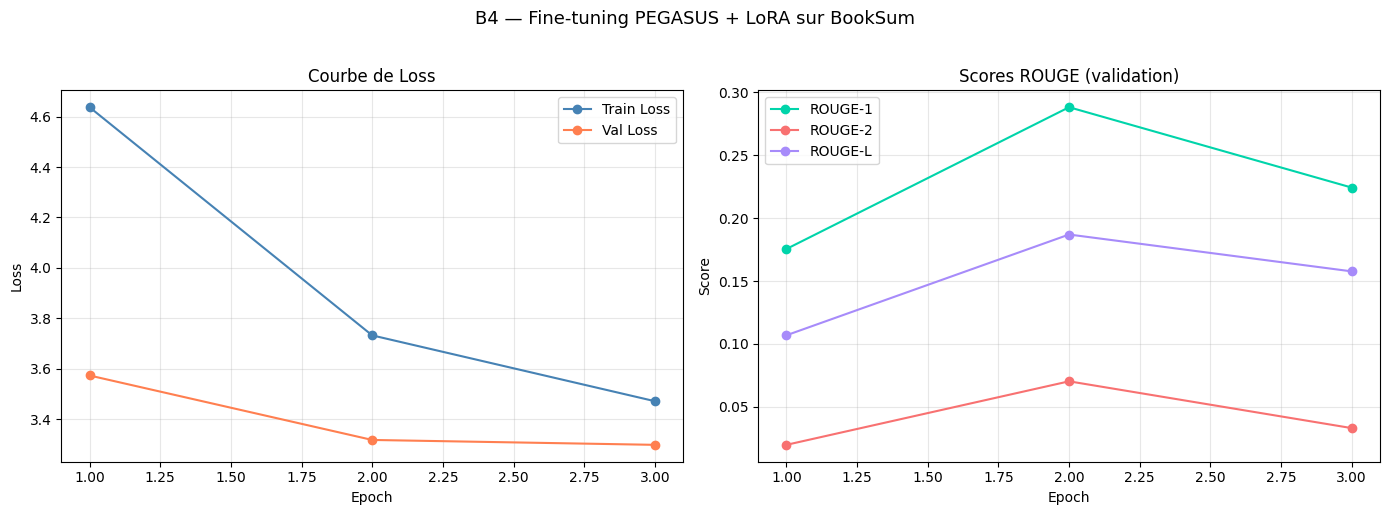

✅ courbes_finetuning.png sauvegardé


In [8]:
import matplotlib.pyplot as plt

epochs     = [h["epoch"]      for h in historique]
train_loss = [h["train_loss"] for h in historique]
val_loss   = [h["val_loss"]   for h in historique]
r1_vals    = [h["rouge1"]     for h in historique]
r2_vals    = [h["rouge2"]     for h in historique]
rl_vals    = [h["rougeL"]     for h in historique]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, train_loss, "o-", color="steelblue", label="Train Loss")
axes[0].plot(epochs, val_loss,   "o-", color="coral",     label="Val Loss")
axes[0].set_title("Courbe de Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, r1_vals, "o-", color="#00d4aa", label="ROUGE-1")
axes[1].plot(epochs, r2_vals, "o-", color="#f87171", label="ROUGE-2")
axes[1].plot(epochs, rl_vals, "o-", color="#a78bfa", label="ROUGE-L")
axes[1].set_title("Scores ROUGE (validation)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("B4 — Fine-tuning PEGASUS + LoRA sur BookSum", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("courbes_finetuning.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ courbes_finetuning.png sauvegardé")

## 8. Export rapport final

In [9]:
meilleur = max(historique, key=lambda h: h["rouge1"])

rapport_final = {
    "modele":           MODEL_NAME,
    "technique":        "LoRA + 8-bit quantization",
    "output_dir":       HYPERPARAMS["output_dir"],
    "hyperparams":      HYPERPARAMS,
    "meilleure_epoch":  meilleur["epoch"],
    "meilleurs_scores": {
        "rouge1": meilleur["rouge1"],
        "rouge2": meilleur["rouge2"],
        "rougeL": meilleur["rougeL"]
    },
    "historique":       historique,
    "message_pour_A4": (
        f"Modèle LoRA disponible dans '{HYPERPARAMS['output_dir']}'. "
        "Charger avec : PeftModel.from_pretrained(base_model, 'model_finetuned')"
    )
}

with open("rapport_finetuning.json", "w", encoding="utf-8") as f:
    json.dump(rapport_final, f, indent=2, ensure_ascii=False)

print("=" * 55)
print(" RÉSULTATS FINAUX — B4 Fine-tuning PEGASUS + LoRA")
print("=" * 55)
print(f"  Meilleure epoch : {meilleur['epoch']}")
print(f"  ROUGE-1         : {meilleur['rouge1']}")
print(f"  ROUGE-2         : {meilleur['rouge2']}")
print(f"  ROUGE-L         : {meilleur['rougeL']}")
print()
print(f"  💾 Modèle sauvegardé dans : {HYPERPARAMS['output_dir']}/")
print(f"  📄 rapport_finetuning.json sauvegardé")
print()
print("  ✅ Personne A peut démarrer A4 (Pipeline Map-Reduce)")

 RÉSULTATS FINAUX — B4 Fine-tuning PEGASUS + LoRA
  Meilleure epoch : 2
  ROUGE-1         : 0.2882
  ROUGE-2         : 0.0703
  ROUGE-L         : 0.187

  💾 Modèle sauvegardé dans : model_finetuned/
  📄 rapport_finetuning.json sauvegardé

  ✅ Personne A peut démarrer A4 (Pipeline Map-Reduce)


## ✅ Résumé B4

| Élément | Valeur |
|---|---|
| Modèle | `google/pegasus-xsum` |
| Technique | LoRA (r=8) + quantization 8-bit |
| Paramètres entraînés | ~4M / 568M (< 1%) |
| VRAM utilisée | ~5 GB / 14.56 GB |
| Input max | 256 tokens |
| Output max | 64 tokens |
| Output | `model_finetuned/` + `rapport_finetuning.json` |

**👉 Personne A charge le modèle dans A4 avec :**
```python
from peft import PeftModel
base  = AutoModelForSeq2SeqLM.from_pretrained('google/pegasus-xsum')
model = PeftModel.from_pretrained(base, 'model_finetuned')
```